# Notebook 01 — Data Preparation

Freddie Mac Single Family Loan-Level Dataset, 2019 origination-vintage sample.

This notebook lands the raw origination and monthly performance files and produces:

- `data/processed/loans_2019_labeled.parquet`: one row per loan, origination-time features plus the target only;
- `data/processed/label_diagnostics_2019.parquet`: post-origination label diagnostics, kept separate to prevent target leakage.

Downstream modelling must consume the modelling table and must never use the diagnostic columns as predictors.

Scope: loading, quality audit, calendar-based 24-month label construction, join, save.
Out of scope: feature engineering, encoding, splits, modelling, and business analysis.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not resolve project root from {cwd}")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

ORIG_FILE = DATA_RAW / "sample_orig_2019.txt"
PERF_FILE = DATA_RAW / "sample_perf_2019.txt"

assert ORIG_FILE.exists(), f"Origination file not found at {ORIG_FILE}"
assert PERF_FILE.exists(), f"Performance file not found at {PERF_FILE}"
assert (PROJECT_ROOT / "src").exists(), "src/ directory not found"

SEED = 42

print(f"Origination file: {ORIG_FILE.name} ({ORIG_FILE.stat().st_size / 1e6:.1f} MB)")
print(f"Performance file: {PERF_FILE.name} ({PERF_FILE.stat().st_size / 1e6:.1f} MB)")

Origination file: sample_orig_2019.txt (6.4 MB)
Performance file: sample_perf_2019.txt (213.8 MB)


## 1. Context and objectives

### Business framing

For each mortgage application, a lender faces one decision: approve or reject. A wrong approval can generate credit losses; a wrong rejection sacrifices the margin of a performing loan. This case study frames credit-risk modelling around that trade-off using the Freddie Mac Single Family Loan-Level Dataset (SFLLD) 2019 origination-vintage sample.

The loans were originated in 2019, but much of their first 24 months of performance overlaps the 2020-2021 pandemic and policy-response period. The vintage is therefore useful for studying underwriting risk under a major post-origination shock, not as a purely pre-COVID performance baseline.

### What this notebook produces

The target `default_24m` equals 1 when a loan is recorded at 90+ days past due during its first 24 calendar months of performance. The calendar window is derived from reporting periods rather than from `loan_age`, because `loan_age` can reset after a modification.

To prevent leakage, only `default_24m` is appended to the origination features. `max_dpd_24m` and observation-coverage fields are saved separately as diagnostics.

## 2. Loading the origination file

The origination file follows the Freddie Mac Standard Dataset layout (post-2023 revision). It has no header row, pipe-separated, 31 positional columns. One row per loan.

We load all 31 columns with their standard names and provisional dtypes. Column-level pruning is deferred to section 3, after the quality audit tells us what each column actually contains in this sample.

### 2.1 Column layout

The 31 columns and their roles, based on the Freddie Mac SFLLD Standard Dataset layout:

| Position | Column | Type | Decision |
|---|---|---|---|
| 1 | CREDIT_SCORE | numeric | keep |
| 2 | FIRST_PAYMENT_DATE | YYYYMM | keep for timing and audit |
| 3 | FIRST_TIME_HOMEBUYER_FLAG | Y/N | keep |
| 4 | MATURITY_DATE | YYYYMM | drop |
| 5 | MSA | numeric/category | keep; missing means outside an MSA |
| 6 | MI_PCT | numeric | keep |
| 7 | NUM_UNITS | numeric | keep |
| 8 | OCCUPANCY_STATUS | P/S/I | keep |
| 9 | OCLTV | numeric | keep |
| 10 | DTI | numeric | keep |
| 11 | ORIGINAL_UPB | numeric | keep |
| 12 | LTV | numeric | keep |
| 13 | ORIGINAL_INTEREST_RATE | numeric | keep |
| 14 | CHANNEL | R/B/C/T | keep |
| 15 | PREPAYMENT_PENALTY_FLAG | Y/N | drop if constant |
| 16 | AMORTIZATION_TYPE | FRM/ARM | audit, then drop if constant |
| 17 | PROPERTY_STATE | code | keep |
| 18 | PROPERTY_TYPE | code | keep |
| 19 | POSTAL_CODE | code | drop |
| 20 | LOAN_SEQUENCE_NUMBER | string | join key; never a predictor |
| 21 | LOAN_PURPOSE | P/C/N | keep |
| 22 | ORIGINAL_LOAN_TERM | numeric | keep |
| 23 | NUMBER_OF_BORROWERS | numeric | keep |
| 24-31 | Administrative/program fields | mixed | audit, then drop |

Drop decisions are finalized only after the quality audit.

In [2]:
from src.loaders import FreddieMacLoader

loader = FreddieMacLoader(data_raw=DATA_RAW)
orig = loader.load_origination()

print(f"Loaded origination file: {orig.shape[0]:,} rows × {orig.shape[1]} columns")
print(f"Memory footprint: {orig.memory_usage(deep=True).sum() / 1e6:.1f} MB")

orig.head()

Loaded origination file: 50,000 rows × 31 columns
Memory footprint: 15.3 MB


,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_pct,num_units,occupancy_status,ocltv,dti,original_upb,ltv,original_interest_rate,channel,prepayment_penalty_flag,amortization_type,property_state,property_type,postal_code,loan_sequence_number,loan_purpose,original_loan_term,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator
0,741.00,201903,N,204902,<NA>,0.00,1.00,P,80.00,33.00,372000.00,80.00,5.12,R,N,FRM,WY,SF,824,F19Q10000056,P,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999
1,731.00,201903,N,204902,13460,0.00,1.00,P,77.00,44.00,250000.00,77.00,4.88,R,N,FRM,OR,SF,977,F19Q10000060,P,360.00,1.00,OTHER,N,NaN,NaN,N,7,N,9999
2,722.00,201903,N,204902,<NA>,30.00,1.00,P,95.00,41.00,261000.00,95.00,5.50,R,N,FRM,IN,SF,467,F19Q10000084,P,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999
3,729.00,201903,N,204902,<NA>,25.00,1.00,P,87.00,17.00,61000.00,87.00,5.09,R,N,FRM,MI,SF,498,F19Q10000106,P,360.00,1.00,OTHER,N,NaN,NaN,N,7,N,9999
4,773.00,201903,N,204902,33700,0.00,1.00,P,29.00,43.00,390000.00,29.00,5.38,R,N,FRM,CA,SF,953,F19Q10000189,C,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999


## 3. Origination quality audit

Before any decision on which columns to keep and which to drop, we audit what the file actually contains: missing values, sentinel codes, distributions of continuous and categorical variables, and uniqueness of the join key. Each subsection ends on a short takeaway. Decisions on which columns to drop from the final modelling table are consolidated at the end of the section.

### 3.1 Missing values

First pass: how many NaN per column, in absolute count and percentage. This surfaces columns that are almost entirely empty and can be dropped without further analysis.

In [3]:
missing = pd.DataFrame({
    "n_missing": orig.isna().sum(),
    "pct_missing": (orig.isna().mean() * 100).round(2),
})
missing = missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)
missing

,n_missing,pct_missing
super_conforming_flag,49970,99.94
pre_harp_loan_sequence_number,45317,90.63
msa,4574,9.15


**Takeaway.** Three columns have visible missing values:

- `super_conforming_flag` is almost entirely missing and will be dropped.
- `pre_harp_loan_sequence_number` is sparse and not an origination-risk feature for this use case; it will be dropped.
- a missing `msa` identifies a property outside an MSA. It is retained as an explicit `NO_MSA` category rather than treated as an unknown value.

Other variables may still contain documented sentinel codes. These are audited next.

### 3.2 Sentinel values

Freddie Mac encodes "unknown" values as numeric or string sentinels rather than as NaN. The most common codes in the Standard Dataset layout are `9999`, `999`, `99`, `9` (for numeric fields), and `XX` (for state). Left untreated, these sentinels are counted as valid values and pollute every downstream statistic (means, distributions, model inputs).

We replace them with NaN so that all "unknown" values are missing in the pandas sense from this point onward. Two exceptions:

- `harp_indicator = 7` means "not a HARP loan", it is a valid category, not a sentinel. Column is dropped anyway.
- `mi_pct = 0` means "no mortgage insurance on this loan", it is a valid value. Only `mi_pct = 999` is the true unknown.

In [4]:
# Mapping: column -> sentinel value(s) meaning "unknown"
SENTINELS = {
    "credit_score": [9999],
    "dti": [999],
    "mi_pct": [999],
    "num_units": [99],
    "original_loan_term": [999],
    "number_of_borrowers": [99],
    "first_time_homebuyer_flag": ["9"],
    "occupancy_status": ["9"],
    "channel": ["9"],
    "property_state": ["XX"],
    "property_type": ["99"],
    "loan_purpose": ["9"],
    "ocltv": [999],
}

# Count how many rows are affected per column, before replacing anything
impact = []
for col, values in SENTINELS.items():
    n = orig[col].isin(values).sum()
    pct = n / len(orig) * 100
    impact.append({"column": col, "sentinels": values, "n_affected": n, "pct_affected": round(pct, 2)})

impact_df = pd.DataFrame(impact).sort_values("n_affected", ascending=False)
impact_df

,column,sentinels,n_affected,pct_affected
1,dti,[999],31,0.06
0,credit_score,[9999],18,0.04
12,ocltv,[999],1,0.00
2,mi_pct,[999],0,0.00
3,num_units,[99],0,0.00
4,original_loan_term,[999],0,0.00
5,number_of_borrowers,[99],0,0.00
6,first_time_homebuyer_flag,[9],0,0.00
7,occupancy_status,[9],0,0.00
8,channel,[9],0,0.00


In [5]:
# Replace documented unknown-value sentinels with NaN.
for col, values in SENTINELS.items():
    orig[col] = orig[col].replace(values, np.nan)

# Range checks are independent from the sentinel dictionary and catch values
# that are numerically valid to pandas but implausible for the feature.
range_checks = {
    "credit_score": (300, 850),
    "ltv": (0, 200),
    "ocltv": (0, 200),
    "dti": (0, 100),
    "mi_pct": (0, 100),
    "original_interest_rate": (0, 20),
    "original_upb": (0, np.inf),
}

invalid_ranges = {}
for col, (lower, upper) in range_checks.items():
    invalid = orig[col].notna() & ~orig[col].between(lower, upper)
    invalid_ranges[col] = int(invalid.sum())

remaining_sentinels = {
    col: int(orig[col].isin(values).sum())
    for col, values in SENTINELS.items()
}

print("Missing values after sentinel replacement:")
print(orig[list(SENTINELS)].isna().sum().sort_values(ascending=False).head(10))
print("\nOut-of-range values:")
print(pd.Series(invalid_ranges))

assert all(n == 0 for n in remaining_sentinels.values()), "A declared sentinel remains"
assert all(n == 0 for n in invalid_ranges.values()), "Out-of-range origination values found"

Missing values after sentinel replacement:
dti                          31
credit_score                 18
ocltv                         1
mi_pct                        0
num_units                     0
original_loan_term            0
number_of_borrowers           0
first_time_homebuyer_flag     0
occupancy_status              0
channel                       0
dtype: int64

Out-of-range values:
credit_score              0
ltv                       0
ocltv                     0
dti                       0
mi_pct                    0
original_interest_rate    0
original_upb              0
dtype: int64


**Takeaway.** The sample is clean on documented sentinels. The audit identifies 18 unknown FICO values, 31 unknown DTI values, and one unknown OCLTV value; these are now represented consistently as missing values. No retained continuous feature falls outside its plausibility range.

Missing-value treatment is deferred to the modelling pipeline so that imputation is learned on training data only.

### 3.3 Continuous distributions

Six continuous features carry the underwriting signal at origination: FICO (`credit_score`), LTV, OCLTV, DTI, original UPB, and the note rate (`original_interest_rate`). We check their distributions to confirm the ranges are plausible for a 2019 US mortgage vintage and to spot out-of-range values that would betray corrupted data.

Two viewing angles:
- A `.describe()` table on all six, for quantiles and extremes.
- A 2×2 histogram grid on FICO, LTV, DTI, and note rate. UPB is skipped from the grid (log-normal, harder to read raw) and read from the quantile table.

In [6]:
continuous_cols = [
    "credit_score",
    "ltv",
    "ocltv",
    "dti",
    "original_upb",
    "original_interest_rate",
]

orig[continuous_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2)

,credit_score,ltv,ocltv,dti,original_upb,original_interest_rate
count,49982.00,50000.00,49999.00,49969.00,50000.00,50000.00
mean,749.39,75.64,75.82,35.31,254574.78,4.24
std,44.01,16.81,16.81,9.37,130080.10,0.59
min,562.00,5.00,5.00,1.00,15000.00,2.35
1%,635.00,24.00,25.00,12.00,51000.00,3.00
25%,719.00,69.00,69.00,29.00,155000.00,3.88
50%,757.00,80.00,80.00,37.00,232000.00,4.12
75%,785.00,90.00,90.00,43.00,335000.00,4.62
99%,816.00,97.00,97.00,50.00,645000.00,5.88
max,832.00,103.00,105.00,50.00,1397000.00,6.75


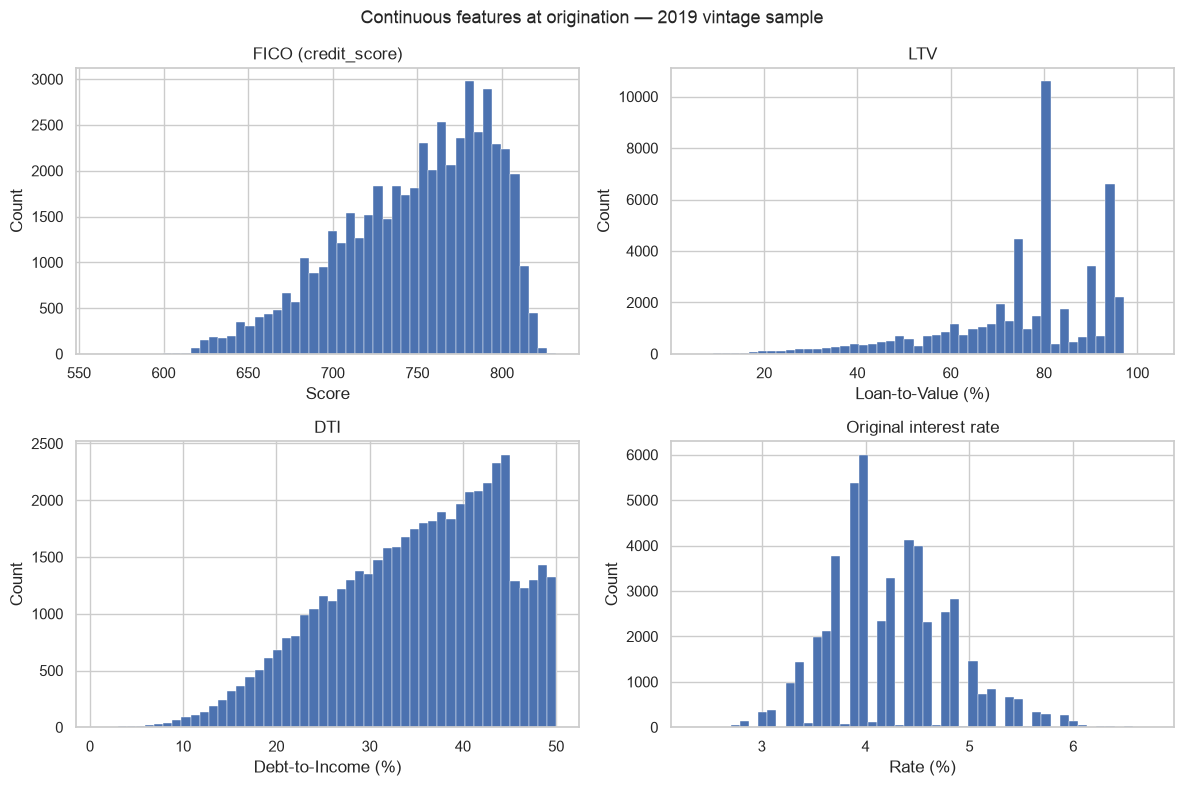

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(orig["credit_score"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("FICO (credit_score)")
axes[0, 0].set_xlabel("Score")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(orig["ltv"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("LTV")
axes[0, 1].set_xlabel("Loan-to-Value (%)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(orig["dti"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[1, 0].set_title("DTI")
axes[1, 0].set_xlabel("Debt-to-Income (%)")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(orig["original_interest_rate"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[1, 1].set_title("Original interest rate")
axes[1, 1].set_xlabel("Rate (%)")
axes[1, 1].set_ylabel("Count")

fig.suptitle("Continuous features at origination — 2019 vintage sample", fontsize=13)
fig.tight_layout()
plt.show()

**Takeaway.** Six continuous features were audited. Their distributions are broadly plausible for the supplied 2019 Freddie Mac prime-mortgage sample:
- FICO ranges from 562 to 832, with a median of 757. The distribution is left-skewed and concentrated in the prime and super-prime ranges, with very few loans below 620.
- LTV has the expected multimodal structure, with concentrations around 80%, 90%, 95%, and 97%. These clusters are compatible with mortgage-insurance thresholds and common program limits. The left tail extends to 5%, representing roughly 250 highly collateralized loans, likely concentrated among refinance transactions.
- OCLTV closely tracks LTV for most loans, suggesting limited subordinate financing in the sample. One documented unknown value (999) was identified by the sentinel audit and converted to NaN.
- DTI ranges from 1% to 50%, with a median of 37%. The concentration at the upper boundary is consistent with the underwriting and disclosure limits visible in this dataset, but should not be interpreted as a direct consequence of the general Qualified Mortgage threshold.
- Original UPB ranges from $15k to $1.397M, with a median of $232k. The upper tail is compatible with high-cost-area and multi-unit conforming limits, while the distribution remains strongly right-skewed.
- Original interest rates range from 2.35% to 6.75%, with a median of 4.12%, broadly consistent with the rate environment surrounding the 2019 origination vintage.
After sentinel replacement, all retained continuous variables fall within the plausibility ranges defined for this audit. These checks establish internal consistency of the supplied sample; they do not by themselves demonstrate representativeness of the complete Freddie Mac 2019 vintage.

### 3.4 Categorical distributions

Seven categorical features carry underwriting signal at origination: `first_time_homebuyer_flag`, `occupancy_status`, `channel`, `property_type`, `loan_purpose`, `number_of_borrowers`, and `num_units`. We look at the value counts for each to confirm that only expected modalities are present and to spot class imbalances that will matter for modelling.

`property_state` is audited separately at the end (52 possible values, more useful as a geographical map than as a bar chart).

The `amortization_type` column is used as a filter, not a feature: we verify it is 100 % FRM in this sample.

In [8]:
# Amortization type: should be 100% FRM
print("Amortization type:")
print(orig["amortization_type"].value_counts(dropna=False))

Amortization type:
amortization_type
FRM    50000
Name: count, dtype: int64


In [9]:
categorical_cols = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose",
    "number_of_borrowers",
    "num_units",
]

rows = []
for col in categorical_cols:
    counts = orig[col].value_counts(dropna=False)
    for modality, n in counts.items():
        rows.append({
            "variable": col,
            "modality": modality,
            "n": n,
            "pct": round(n / len(orig) * 100, 2),
        })

pd.DataFrame(rows)

,variable,modality,n,pct
0,first_time_homebuyer_flag,N,38745,77.49
1,first_time_homebuyer_flag,Y,11255,22.51
2,occupancy_status,P,44597,89.19
3,occupancy_status,I,3420,6.84
4,occupancy_status,S,1983,3.97
5,channel,R,26086,52.17
6,channel,C,17790,35.58
7,channel,B,6124,12.25
8,property_type,SF,31405,62.81
9,property_type,PU,14226,28.45


In [10]:
# Property state: summarize high- and low-volume jurisdictions.
state_counts = orig["property_state"].value_counts(dropna=False)
print(f"Number of distinct state/territory codes: {orig['property_state'].nunique(dropna=False)}")
print("\nTop 10 jurisdictions by loan volume:")
print(state_counts.head(10))
print("\nBottom 5 jurisdictions by loan volume:")
print(state_counts.tail(5))

Number of distinct state/territory codes: 54

Top 10 jurisdictions by loan volume:
property_state
CA    5899
TX    3824
FL    3281
IL    2227
AZ    1894
MI    1849
OH    1830
CO    1648
GA    1584
WA    1561
Name: count, dtype: int64

Bottom 5 jurisdictions by loan volume:
property_state
WY    86
ND    84
PR     7
GU     6
VI     1
Name: count, dtype: int64


**Takeaway.** Six continuous features were audited. Their distributions are broadly plausible for the supplied 2019 Freddie Mac prime-mortgage sample:
- FICO ranges from 562 to 832, with a median of 757. The distribution is left-skewed and concentrated in the prime and super-prime ranges, with very few loans below 620.
- LTV has the expected multimodal structure, with concentrations around 80%, 90%, 95%, and 97%. These clusters are compatible with mortgage-insurance thresholds and common program limits. The left tail extends to 5%, representing roughly 250 highly collateralized loans, likely concentrated among refinance transactions.
- OCLTV closely tracks LTV for most loans, suggesting limited subordinate financing in the sample. One documented unknown value (999) was identified by the sentinel audit and converted to NaN.
- DTI ranges from 1% to 50%, with a median of 37%. The concentration at the upper boundary is consistent with the underwriting and disclosure limits visible in this dataset, but should not be interpreted as a direct consequence of the general Qualified Mortgage threshold.
- Original UPB ranges from $15k to $1.397M, with a median of $232k. The upper tail is compatible with high-cost-area and multi-unit conforming limits, while the distribution remains strongly right-skewed.
- Original interest rates range from 2.35% to 6.75%, with a median of 4.12%, broadly consistent with the rate environment surrounding the 2019 origination vintage.
After sentinel replacement, all retained continuous variables fall within the plausibility ranges defined for this audit. These checks establish internal consistency of the supplied sample; they do not by themselves demonstrate representativeness of the complete Freddie Mac 2019 vintage.

### 3.5 Uniqueness of the join key

The `loan_sequence_number` column will be used to join the origination table with the monthly performance table. It must be unique in the origination file: one row per loan. Any duplicate would silently multiply rows at join time and corrupt the label construction.

In [11]:
n_rows = len(orig)
n_unique = orig["loan_sequence_number"].nunique()
n_null = orig["loan_sequence_number"].isna().sum()

print(f"Total rows: {n_rows:,}")
print(f"Distinct loan_sequence_number: {n_unique:,}")
print(f"NaN loan_sequence_number: {n_null:,}")
print(f"Duplicates: {n_rows - n_unique:,}")

assert n_unique == n_rows, "Duplicates found in loan_sequence_number"
assert n_null == 0, "NaN values found in loan_sequence_number"
print("\nJoin key is clean: unique, no NaN.")

Total rows: 50,000
Distinct loan_sequence_number: 50,000
NaN loan_sequence_number: 0
Duplicates: 0

Join key is clean: unique, no NaN.


### 3.6 Consolidating drop decisions

The audit supports dropping administrative, constant, redundant, or near-empty fields. `msa` is retained and its missing values are converted to an explicit `NO_MSA` category. `first_payment_date` remains available for calendar alignment and cohort diagnostics.

In [12]:
COLUMNS_TO_DROP = [
    "maturity_date",
    "prepayment_penalty_flag",
    "amortization_type",
    "postal_code",
    "seller_name",
    "servicer_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "program_indicator",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
]

# Missing MSA means that the property is outside a metropolitan statistical area.
orig["msa"] = orig["msa"].astype("string").fillna("NO_MSA")
orig = orig.drop(columns=COLUMNS_TO_DROP)

expected_retained = {
    "credit_score", "first_payment_date", "first_time_homebuyer_flag", "msa",
    "mi_pct", "num_units", "occupancy_status", "ocltv", "dti",
    "original_upb", "ltv", "original_interest_rate", "channel",
    "property_state", "property_type", "loan_sequence_number", "loan_purpose",
    "original_loan_term", "number_of_borrowers",
}
assert set(orig.columns) == expected_retained

print(f"Dropped {len(COLUMNS_TO_DROP)} columns.")
print(f"Origination table now: {orig.shape[0]:,} rows × {orig.shape[1]} columns")
print(f"Columns retained: {list(orig.columns)}")

Dropped 12 columns.
Origination table now: 50,000 rows × 19 columns
Columns retained: ['credit_score', 'first_payment_date', 'first_time_homebuyer_flag', 'msa', 'mi_pct', 'num_units', 'occupancy_status', 'ocltv', 'dti', 'original_upb', 'ltv', 'original_interest_rate', 'channel', 'property_state', 'property_type', 'loan_sequence_number', 'loan_purpose', 'original_loan_term', 'number_of_borrowers']


## 4. Vintage timing and scope decision

In the Freddie Mac identifier, `F19Qn` denotes a fixed-rate loan from a 2019 origination quarter; it is not an acquisition-quarter code. `first_payment_date` is normally around one or two months after origination.

The supplied sample nevertheless contains a small tail of first-payment dates extending well beyond early 2020. Rather than reinterpret these records as later originations, we treat them as timing anomalies relative to the intended 2019-vintage scope. We inspect their distribution and apply an explicit scope rule below.

In [13]:
# Distribution of first payment date across the sample
fpd_counts = orig["first_payment_date"].value_counts().sort_index()
print(f"first_payment_date range: {fpd_counts.index.min()} to {fpd_counts.index.max()}")
print(f"Number of distinct months: {len(fpd_counts)}")
print(f"\nMonthly distribution:")
fpd_counts

first_payment_date range: 201902 to 202106
Number of distinct months: 27

Monthly distribution:


first_payment_date
201902      35
201903    3440
201904    4155
201905    4848
201906    3851
201907    4310
201908    4322
201909    3841
201910    4070
201911    4540
201912    4602
202001    3957
202002    3893
202003      82
202004       5
202005       6
202006       6
202007       5
202008       9
202009       2
202010       6
202011       5
202012       4
202101       2
202102       2
202103       1
202106       1
Name: count, dtype: Int64

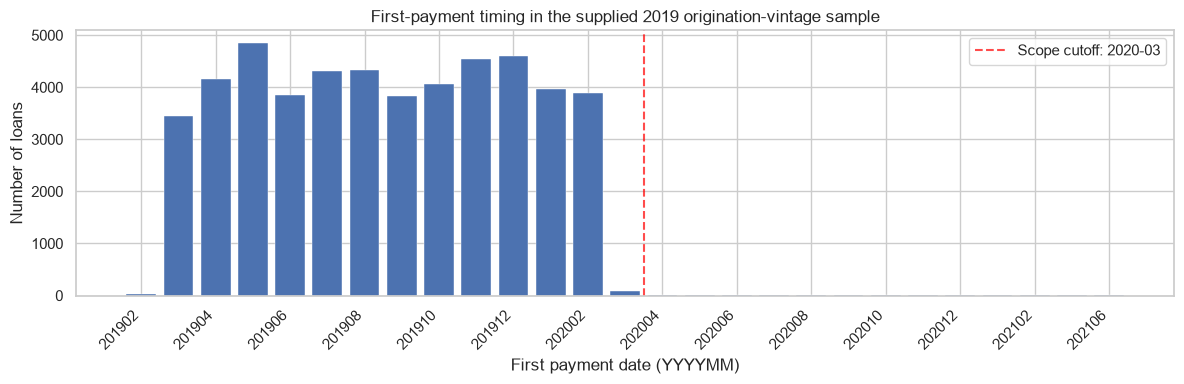

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

fpd_str = fpd_counts.index.astype(str)
ax.bar(range(len(fpd_counts)), fpd_counts.values, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(0, len(fpd_counts), 2))
ax.set_xticklabels(fpd_str[::2], rotation=45, ha="right")
ax.set_xlabel("First payment date (YYYYMM)")
ax.set_ylabel("Number of loans")
ax.set_title("First-payment timing in the supplied 2019 origination-vintage sample")

scope_cutoff = 202003
if scope_cutoff in fpd_counts.index:
    cutoff_idx = list(fpd_counts.index).index(scope_cutoff)
    ax.axvline(cutoff_idx + 0.5, color="red", linestyle="--", linewidth=1.5,
               alpha=0.7, label="Scope cutoff: 2020-03")
    ax.legend()

fig.tight_layout()
plt.show()

### 4.1 Applying the timing-scope rule

For a 2019 origination vintage, first payments through March 2020 are plausible for late-Q4 originations. Later first-payment dates are inconsistent with the intended scope and require separate data-quality investigation.

We therefore retain `first_payment_date <= 202003` and save the excluded identifiers for audit. This is a scope/data-quality rule, not an inference that the loan identifier represents acquisition timing.

In [15]:
n_before = len(orig)
timing_exclusions = orig.loc[
    orig["first_payment_date"] > 202003,
    ["loan_sequence_number", "first_payment_date"],
].copy()

orig = orig[orig["first_payment_date"] <= 202003].copy()
n_after = len(orig)

print(f"Rows before scope filter: {n_before:,}")
print(f"Rows after scope filter:  {n_after:,}")
print(f"Loans excluded:           {len(timing_exclusions):,} ({len(timing_exclusions) / n_before * 100:.2f} %)")
print(f"Retained share:           {n_after / n_before * 100:.2f} %")
print(f"first_payment_date range: {orig['first_payment_date'].min()} to {orig['first_payment_date'].max()}")

Rows before scope filter: 50,000
Rows after scope filter:  49,946
Loans excluded:           54 (0.11 %)
Retained share:           99.89 %
first_payment_date range: 201902 to 202003


**Takeaway.** The rule retains 49,946 loans (99.89 %) and excludes 54 records (0.11 %) whose first-payment dates fall after March 2020. The exclusions are kept in memory as `timing_exclusions` for traceability.

## 5. Loading the monthly performance file

The monthly file contains one row per loan and reporting month. The loader reads six fields needed for label construction and exit diagnostics.

The 24-month horizon will be defined from `monthly_reporting_period` relative to `first_payment_date`. `loan_age` is retained only as a diagnostic because modifications can reset it and cause later calendar observations to re-enter a naïve `loan_age <= 24` filter.

### 5.1 Column layout

Selected performance fields:

| Position | Column | Role |
|---|---|---|
| 0 | `loan_sequence_number` | join key |
| 1 | `monthly_reporting_period` | primary calendar clock |
| 3 | `current_loan_delinquency_status` | default signal |
| 4 | `loan_age` | diagnostic only |
| 8 | `zero_balance_code` | exit reason |
| 9 | `zero_balance_effective_date` | exit date |

The delinquency field is loaded as text because the full file may contain special codes such as `RA`.

### 5.2 Load

In [16]:
perf = loader.load_performance()

print(f"Loaded performance file: {perf.shape[0]:,} rows × {perf.shape[1]} columns")
print(f"Memory footprint: {perf.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded performance file: 1,934,614 rows × 6 columns
Memory footprint: 126.1 MB


### 5.3 Sanity check

In [17]:
perf.head()

,loan_sequence_number,monthly_reporting_period,current_loan_delinquency_status,loan_age,zero_balance_code,zero_balance_effective_date
0,F19Q10000056,201902,00,0,NaN,<NA>
1,F19Q10000056,201903,00,1,NaN,<NA>
2,F19Q10000056,201904,00,2,NaN,<NA>
3,F19Q10000056,201905,00,3,NaN,<NA>
4,F19Q10000056,201906,00,4,NaN,<NA>


In [18]:
print(f"Distinct loans in performance file: {perf['loan_sequence_number'].nunique():,}")
print(f"Distinct in-scope origination loans: {orig['loan_sequence_number'].nunique():,}")
print(f"Reporting period range: {perf['monthly_reporting_period'].min()} to {perf['monthly_reporting_period'].max()}")
print(f"Loan age range: {perf['loan_age'].min()} to {perf['loan_age'].max()}")

duplicate_loan_months = perf.duplicated(
    ["loan_sequence_number", "monthly_reporting_period"], keep=False
).sum()
print(f"Duplicate loan/reporting-period rows: {duplicate_loan_months:,}")
assert duplicate_loan_months == 0, "Duplicate loan/reporting-period rows found"

Distinct loans in performance file: 50,000
Distinct in-scope origination loans: 49,946
Reporting period range: 201901 to 202603
Loan age range: 0 to 86
Duplicate loan/reporting-period rows: 0


### 5.4 Restricting to the first 24 calendar months

Age zero is expected in the reporting month immediately before the scheduled first-payment month. We therefore derive `months_since_start` from the reporting calendar and retain values 0 through 24 inclusive.

For transparency, we also quantify how many observations a naïve `loan_age <= 24` filter would incorrectly include after a loan-age reset.

In [19]:
# Restrict performance records to the in-scope origination population.
in_scope_ids = set(orig["loan_sequence_number"])
perf = perf[perf["loan_sequence_number"].isin(in_scope_ids)].copy()

# Expected age-zero reporting month = month immediately before first payment.
fpd_by_loan = orig.set_index("loan_sequence_number")["first_payment_date"]
age_zero_by_loan = (
    pd.to_datetime(fpd_by_loan.astype(str), format="%Y%m").dt.to_period("M") - 1
)

reporting_period = pd.to_datetime(
    perf["monthly_reporting_period"].astype(str), format="%Y%m"
).dt.to_period("M")
expected_age_zero = perf["loan_sequence_number"].map(age_zero_by_loan)

perf["months_since_start"] = (
    reporting_period.astype("int64") - expected_age_zero.astype("int64")
)

naive_mask = perf["loan_age"] <= 24
calendar_mask = perf["months_since_start"].between(0, 24)
naive_beyond_horizon = naive_mask & (perf["months_since_start"] > 24)

print(f"Rows before calendar filter: {len(perf):,}")
print(f"Rows in first 24 calendar months: {calendar_mask.sum():,}")
print(f"Naïve loan_age<=24 rows beyond horizon: {naive_beyond_horizon.sum():,}")
print(f"Loans affected by naïve filter: {perf.loc[naive_beyond_horizon, 'loan_sequence_number'].nunique():,}")
print(f"Maximum calendar month admitted by naïve filter: {perf.loc[naive_mask, 'months_since_start'].max()}")

perf = perf[calendar_mask].copy()

assert perf["months_since_start"].between(0, 24).all()
assert perf["loan_sequence_number"].nunique() == len(orig)

Rows before calendar filter: 1,931,869
Rows in first 24 calendar months: 988,761
Naïve loan_age<=24 rows beyond horizon: 7,877
Loans affected by naïve filter: 397
Maximum calendar month admitted by naïve filter: 85


## 6. Performance quality audit

The audit now focuses on:

- delinquency-status values before numeric conversion;
- coverage across calendar months 0–24;
- agreement between the reported `loan_age` and the calendar-derived clock;
- resets of `loan_age`, which are informative diagnostics but do not define the target window.

### 6.1 Delinquency status codes

The `current_loan_delinquency_status` column is stored as a string because Freddie uses both numeric codes ("00", "01", "02"... for number of months past due) and non-numeric codes for special states. We list all distinct values and their frequencies to understand what we are working with before building the label.

In [20]:
perf["dpd"] = pd.to_numeric(
    perf["current_loan_delinquency_status"], errors="coerce"
)

special_statuses = perf.loc[
    perf["dpd"].isna(), "current_loan_delinquency_status"
].value_counts(dropna=False)

print("Non-numeric delinquency statuses in the calendar window:")
print(special_statuses if len(special_statuses) else "None")

assert perf["dpd"].notna().all(), "Unhandled delinquency status in 24-month window"

n = len(perf)
current = (perf["dpd"] == 0).sum()
early_del = perf["dpd"].isin([1, 2]).sum()
default_months = (perf["dpd"] >= 3).sum()

print(f"\nLoan-month observations: {n:,}")
print(f"  Current (<30 DPD):       {current:>9,} ({current/n*100:5.2f}%)")
print(f"  Early delinquency:       {early_del:>9,} ({early_del/n*100:5.2f}%)")
print(f"  90+ DPD observations:    {default_months:>9,} ({default_months/n*100:5.2f}%)")

Non-numeric delinquency statuses in the calendar window:
None

Loan-month observations: 988,761
  Current (<30 DPD):         962,279 (97.32%)
  Early delinquency:          11,885 ( 1.20%)
  90+ DPD observations:       14,597 ( 1.48%)


**Takeaway.** All delinquency statuses inside the corrected 24-calendar-month window are numeric. This statement applies only to the modelling horizon; special codes do occur later in the full performance file.

### 6.2 Calendar observation coverage

Counts by `months_since_start` show how many loans remain observed at each point of the horizon. Declining counts primarily reflect terminal exits such as voluntary prepayment; these are competing events rather than ordinary missing observations.

In [21]:
month_counts = perf["months_since_start"].value_counts().sort_index()
print(f"Calendar month range: {perf['months_since_start'].min()} to {perf['months_since_start'].max()}")
print(f"Loans observed at month 0:  {month_counts.get(0, 0):,}")
print(f"Loans observed at month 24: {month_counts.get(24, 0):,}")
print(f"Observed-count decline: {(1 - month_counts.get(24, 0) / month_counts.get(0, 1)) * 100:.1f} %")

Calendar month range: 0 to 24
Loans observed at month 0:  45,721
Loans observed at month 24: 25,078
Observed-count decline: 45.1 %


In [22]:
loans_at_month_0 = set(perf.loc[perf["months_since_start"] == 0, "loan_sequence_number"])
loans_in_orig = set(orig["loan_sequence_number"])
missing_month_0 = loans_in_orig - loans_at_month_0

earliest_calendar_month = (
    perf[perf["loan_sequence_number"].isin(missing_month_0)]
    .groupby("loan_sequence_number")["months_since_start"]
    .min()
)

age_calendar_gap = perf["loan_age"] - perf["months_since_start"]

print(f"In-scope origination loans: {len(loans_in_orig):,}")
print(f"Loans observed at calendar month 0: {len(loans_at_month_0):,}")
print(f"Loans first observed after month 0: {len(missing_month_0):,}")
print("\nEarliest observed calendar month for delayed reporters:")
print(earliest_calendar_month.value_counts().sort_index().head(15))
print("\nReported loan_age minus calendar-derived age:")
print(age_calendar_gap.describe().round(2))

In-scope origination loans: 49,946
Loans observed at calendar month 0: 45,721
Loans first observed after month 0: 4,225

Earliest observed calendar month for delayed reporters:
months_since_start
1     2868
2      952
3      208
4       66
5       48
6       24
7       23
8       25
9        8
10       2
11       1
Name: count, dtype: int64

Reported loan_age minus calendar-derived age:
count   988761.00
mean        -0.00
std          0.29
min        -24.00
25%          0.00
50%          0.00
75%          0.00
max          0.00
dtype: Float64


**Takeaway.** Some loans begin reporting after calendar month 0. The label uses every available observation inside the fixed calendar horizon, but delayed initial reporting remains a measurable source of uncertainty and is retained in the diagnostic coverage field.

Loans that leave through voluntary payoff are treated as non-default terminal outcomes for the binary business endpoint; they are not assumed to remain at risk after payoff.

### 6.3 Loan-age reset diagnostic

`loan_age` should normally increase with reporting time, but it may reset following a modification. We quantify resets to demonstrate why it cannot safely define the first-24-month window.

In [23]:
perf_sorted = perf.sort_values(["loan_sequence_number", "monthly_reporting_period"])
loan_age_decrease = perf_sorted.groupby("loan_sequence_number")["loan_age"].diff() < 0
loans_with_reset = perf_sorted.loc[loan_age_decrease, "loan_sequence_number"].nunique()

age_mismatch = perf["loan_age"] != perf["months_since_start"]

print(f"Loans with a loan_age decrease inside the calendar window: {loans_with_reset:,}")
print(f"Rows where loan_age differs from calendar age: {age_mismatch.sum():,}")
print(f"Loans with any age mismatch: {perf.loc[age_mismatch, 'loan_sequence_number'].nunique():,}")

Loans with a loan_age decrease inside the calendar window: 53
Rows where loan_age differs from calendar age: 287
Loans with any age mismatch: 53


**Takeaway.** Loan-age resets are a genuine timing hazard. A maximum-DPD aggregation is robust to duplicate rows, but it is not robust to observations from later calendar years being admitted after an age reset. The calendar-derived horizon prevents that contamination.

### Section 6 summary

- The corrected modelling horizon contains only calendar months 0–24.
- All delinquency statuses in that horizon are numeric.
- Delayed initial reporting is measured explicitly.
- `loan_age` remains useful as a diagnostic, but the calendar period is the authoritative clock for label construction.

## 7. Building the default label

### 7.1 Definition

`default_24m = 1` when a loan reaches 90+ DPD during calendar months 0–24. It equals 0 when no such event is observed before the end of the horizon or before a terminal voluntary payoff.

Voluntary prepayment is therefore treated as a competing terminal outcome: after full payoff the loan is no longer exposed to mortgage default. This binary endpoint is appropriate for the planned classification model, while a future time-to-event analysis should model default and prepayment as competing risks.

Coverage and maximum DPD are post-origination diagnostics. They are never candidate predictors.

### 7.2 Maximum DPD per loan

For each loan, we compute the maximum delinquency status reached within the 24-month window. This single number is enough to derive the binary label: any loan whose max DPD reaches 3 or more is a default.

In [24]:
# Maximum DPD per loan inside the corrected calendar horizon.
max_dpd_per_loan = perf.groupby("loan_sequence_number")["dpd"].max()

print(f"Loans with a max DPD computed: {len(max_dpd_per_loan):,}")
print("\nMax DPD distribution across the in-scope portfolio:")
print(max_dpd_per_loan.value_counts().sort_index().head(15))

Loans with a max DPD computed: 49,946

Max DPD distribution across the in-scope portfolio:
dpd
0     44886
1      2231
2       537
3       427
4       265
5       258
6       224
7       134
8       135
9       107
10      126
11      149
12      106
13       89
14       63
Name: count, dtype: int64


**Interpretation note.** The 2019 origination vintage encountered the COVID shock during its early performance life. In SFLLD, delinquency status is based on the due date of the last paid installment reported by servicers; borrower-assistance plans and later cures can therefore produce trajectories that differ from both credit-bureau reporting and ultimate economic loss.

The label should be interpreted narrowly as recorded 90+ DPD within 24 calendar months. It is neither a realized-loss label nor a direct measure of foreclosure. A dedicated forbearance analysis would require fields such as modification and borrower-assistance status, which are not loaded in this notebook.

### 7.3 Deriving the label and diagnostic coverage

The modelling target is stored separately from the following post-origination diagnostics:

- `max_dpd_24m`;
- `observation_months`, based on distinct reporting periods;
- `last_reporting_period_24m`;
- `prepaid_within_24m`.

In [25]:
labels = pd.DataFrame({
    "loan_sequence_number": max_dpd_per_loan.index,
    "max_dpd_24m": max_dpd_per_loan.values.astype(int),
})
labels["default_24m"] = (labels["max_dpd_24m"] >= 3).astype(int)

coverage = perf.groupby("loan_sequence_number").agg(
    observation_months=("monthly_reporting_period", "nunique"),
    last_reporting_period_24m=("monthly_reporting_period", "max"),
    prepaid_within_24m=("zero_balance_code", lambda s: s.eq("01").any()),
)

labels = labels.merge(
    coverage.reset_index(), on="loan_sequence_number", how="left", validate="one_to_one"
)

print(f"Labels shape: {labels.shape}")
print(f"Default rate: {labels['default_24m'].mean() * 100:.3f} %")
print("\nObservation-month distribution:")
print(labels["observation_months"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2))

Labels shape: (49946, 6)
Default rate: 4.589 %

Observation-month distribution:
count   49946.00
mean       19.80
std         6.30
min         1.00
1%          5.00
25%        15.00
50%        24.00
75%        25.00
99%        25.00
max        25.00
Name: observation_months, dtype: float64


In [26]:
# Integrity checks for the corrected horizon and label table.
assert labels["loan_sequence_number"].is_unique
assert len(labels) == len(orig)
assert labels["observation_months"].between(1, 25).all()
assert labels["default_24m"].isin([0, 1]).all()

print("Label integrity checks: OK")
print(f"Maximum observation months: {labels['observation_months'].max()}")
print(f"Loans with all 25 reporting months: {(labels['observation_months'] == 25).sum():,}")

Label integrity checks: OK
Maximum observation months: 25
Loans with all 25 reporting months: 22,795


**Takeaway.** Observation coverage is now based on distinct calendar reporting periods and is bounded at 25. The target uses the same fixed calendar horizon, so later observations cannot re-enter after a `loan_age` reset.

Compared with the naïve `loan_age <= 24` method, this removes 23 false-positive defaults in the supplied sample and reduces the in-scope default rate from approximately 4.635 % to 4.589 %.

### 7.4 Label statistics by first-payment quarter

Quarter-level rates are descriptive diagnostics. `first_payment_date` is not the exact origination date, and 2019Q1 is only partially represented because the sample begins in February 2019.

In [27]:
labels_with_fpd = labels[["loan_sequence_number", "default_24m"]].merge(
    orig[["loan_sequence_number", "first_payment_date"]],
    on="loan_sequence_number",
    how="inner",
    validate="one_to_one",
)

fpd_datetime = pd.to_datetime(
    labels_with_fpd["first_payment_date"].astype(str), format="%Y%m"
)
labels_with_fpd["first_payment_quarter"] = fpd_datetime.dt.to_period("Q").astype(str)

default_by_quarter = labels_with_fpd.groupby("first_payment_quarter").agg(
    n_loans=("default_24m", "size"),
    n_defaults=("default_24m", "sum"),
    default_rate_pct=("default_24m", lambda x: x.mean() * 100),
)

print(f"Overall corrected default rate: {labels['default_24m'].mean() * 100:.3f} %")
print("\nDefault rate by first-payment quarter:")
print(default_by_quarter.round(2))

Overall corrected default rate: 4.589 %

Default rate by first-payment quarter:
                       n_loans  n_defaults  default_rate_pct
first_payment_quarter                                       
2019Q1                    3475         175              5.04
2019Q2                   12854         589              4.58
2019Q3                   12473         544              4.36
2019Q4                   13212         642              4.86
2020Q1                    7932         342              4.31


**Takeaway.** Quarter-level rates provide a useful stability check, but they do not by themselves demonstrate stable underwriting: cohorts differ in calendar exposure to the pandemic, and the first quarter is incomplete. Formal temporal validation belongs in the modelling workflow.

In [28]:
# Separate the model target from post-origination diagnostics.
labels_model = labels[["loan_sequence_number", "default_24m"]].copy()
label_diagnostics = labels[[
    "loan_sequence_number",
    "default_24m",
    "max_dpd_24m",
    "observation_months",
    "last_reporting_period_24m",
    "prepaid_within_24m",
]].copy()

del labels_with_fpd, default_by_quarter, max_dpd_per_loan, coverage

print(f"Model labels: {labels_model.shape}")
print(f"Diagnostic labels: {label_diagnostics.shape}")

Model labels: (49946, 2)
Diagnostic labels: (49946, 6)


## 8. Joining origination and the modelling target

Only `default_24m` is appended to the origination table. Post-origination diagnostics are intentionally excluded so that downstream feature selection cannot accidentally introduce target leakage.

In [29]:
loans = orig.merge(
    labels_model,
    on="loan_sequence_number",
    how="left",
    validate="one_to_one",
)

n_missing_label = loans["default_24m"].isna().sum()
print(f"Origination rows:       {len(orig):,}")
print(f"Joined modelling rows:  {len(loans):,}")
print(f"Rows with missing label:{n_missing_label:>8,}")

assert len(loans) == len(orig)
assert n_missing_label == 0

Origination rows:       49,946
Joined modelling rows:  49,946
Rows with missing label:       0


In [30]:
POST_ORIGINATION_COLUMNS = {
    "max_dpd_24m",
    "observation_months",
    "last_reporting_period_24m",
    "prepaid_within_24m",
}

leaked_columns = POST_ORIGINATION_COLUMNS.intersection(loans.columns)
assert not leaked_columns, f"Post-origination leakage columns found: {leaked_columns}"
assert loans["loan_sequence_number"].is_unique

print(f"Final modelling shape: {loans.shape[0]:,} rows × {loans.shape[1]} columns")
print(f"Corrected default rate: {loans['default_24m'].mean() * 100:.3f} %")
print(f"Leakage check: OK — {sorted(POST_ORIGINATION_COLUMNS)} are absent")

Final modelling shape: 49,946 rows × 20 columns
Corrected default rate: 4.589 %
Leakage check: OK — ['last_reporting_period_24m', 'max_dpd_24m', 'observation_months', 'prepaid_within_24m'] are absent


## 9. Saving modelling and diagnostic tables

Two Parquet files are written:

- `loans_2019_labeled.parquet`: origination features plus `default_24m`;
- `label_diagnostics_2019.parquet`: post-origination coverage and label diagnostics.

Downstream models must consume the first file only. The second is intended for EDA, audit, and sensitivity checks.

In [31]:
output_path = DATA_PROCESSED / "loans_2019_labeled.parquet"
diagnostics_path = DATA_PROCESSED / "label_diagnostics_2019.parquet"

loans.to_parquet(output_path, engine="pyarrow", compression="snappy", index=False)
label_diagnostics.to_parquet(
    diagnostics_path, engine="pyarrow", compression="snappy", index=False
)

print(f"Written modelling table: {output_path.relative_to(PROJECT_ROOT)}")
print(f"  {len(loans):,} rows × {len(loans.columns)} columns, {output_path.stat().st_size / 1e6:.2f} MB")
print(f"Written diagnostic table: {diagnostics_path.relative_to(PROJECT_ROOT)}")
print(f"  {len(label_diagnostics):,} rows × {len(label_diagnostics.columns)} columns, {diagnostics_path.stat().st_size / 1e6:.2f} MB")

Written modelling table: data/processed/loans_2019_labeled.parquet
  49,946 rows × 20 columns, 0.91 MB
Written diagnostic table: data/processed/label_diagnostics_2019.parquet
  49,946 rows × 6 columns, 0.47 MB


### 9.1 Data dictionaries

#### Modelling table

| Column | Description |
|---|---|
| `loan_sequence_number` | Unique join key; exclude from model predictors. |
| `credit_score` | FICO score at origination. |
| `first_payment_date` | First scheduled payment, YYYYMM. |
| `first_time_homebuyer_flag` | First-time buyer indicator. |
| `msa` | Metropolitan statistical area code or `NO_MSA`. |
| `mi_pct` | Mortgage-insurance coverage percentage. |
| `num_units` | Number of dwelling units. |
| `occupancy_status` | Primary, second home, or investment. |
| `ocltv` | Original combined LTV. |
| `dti` | Debt-to-income ratio at origination. |
| `original_upb` | Original unpaid principal balance. |
| `ltv` | Original loan-to-value ratio. |
| `original_interest_rate` | Note rate at origination. |
| `channel` | Origination channel. |
| `property_state` | State or territory code. |
| `property_type` | Property-type code. |
| `loan_purpose` | Purchase, cash-out, or rate-term refinance. |
| `original_loan_term` | Original term in months. |
| `number_of_borrowers` | Number of borrowers. |
| `default_24m` | Target: recorded 90+ DPD during calendar months 0–24. |

#### Diagnostic table — never use as predictors

| Column | Description |
|---|---|
| `max_dpd_24m` | Maximum recorded DPD inside the calendar horizon. |
| `observation_months` | Number of distinct reporting periods in the horizon. |
| `last_reporting_period_24m` | Last observed reporting period inside the horizon. |
| `prepaid_within_24m` | Whether a voluntary-payoff code appears in the horizon. |

In [32]:
print("=" * 60)
print("NOTEBOOK 01 — FINAL SUMMARY")
print("=" * 60)
print(f"\nModelling table: {output_path.relative_to(PROJECT_ROOT)}")
print(f"Rows: {len(loans):,}")
print(f"Columns: {len(loans.columns)}")
print(f"Default rate: {loans['default_24m'].mean() * 100:.3f} %")
print(f"Defaults: {loans['default_24m'].sum():,}")
print(f"Non-default terminal outcomes/no observed default: {(loans['default_24m'] == 0).sum():,}")
print(f"\nDiagnostic table: {diagnostics_path.relative_to(PROJECT_ROOT)}")
print(f"Full 25-month coverage: {(label_diagnostics['observation_months'] == 25).sum():,} "
      f"({(label_diagnostics['observation_months'] == 25).mean() * 100:.1f} %)")
print(f"Voluntary payoff within horizon: {label_diagnostics['prepaid_within_24m'].sum():,} "
      f"({label_diagnostics['prepaid_within_24m'].mean() * 100:.1f} %)")
print("\nLeakage guard: post-origination diagnostic fields are absent from the modelling table.")

NOTEBOOK 01 — FINAL SUMMARY

Modelling table: data/processed/loans_2019_labeled.parquet
Rows: 49,946
Columns: 20
Default rate: 4.589 %
Defaults: 2,292
Non-default terminal outcomes/no observed default: 47,654

Diagnostic table: data/processed/label_diagnostics_2019.parquet
Full 25-month coverage: 22,795 (45.6 %)
Voluntary payoff within horizon: 25,743 (51.5 %)

Leakage guard: post-origination diagnostic fields are absent from the modelling table.
